# CHURN

**Variables Importantes:**
- **change_mou y change_rev** (Cambio en minutos y facturación): . Un descenso brusco y reciente en el uso del servicio o en lo que el cliente paga es uno de los indicadores más claros de que está probando a otro proveedor o se está preparando para irse.
- **drop_blk_mean** (Media de llamadas caídas y bloqueadas): Mide directamente la calidad del servicio. Un cliente que experimenta muchas llamadas fallidas es un cliente insatisfecho y con una alta probabilidad de abandonar la compañía.
- **custcare_mean**  (Media de llamadas a atención al cliente): Un número elevado de llamadas a soporte suele ser sinónimo de problemas. 
- **ovrrev_mean y ovrmou_mean** (Ingresos y minutos por uso extra):  El "susto en la factura" es una causa clásica de churn. Clientes que pagan de más de forma recurrente por salirse de su tarifa suelen estar muy descontentos.
- **months (meses en servicio)**:La antigüedad del cliente es un factor clave. Clientes más nuevos tienen una menor lealtad y es más probable que se vayan si no están satisfechos, mientras que los clientes más antiguos suelen ser más fieles.
- **eqpdays** (Días con el equipo actual): La antigüedad del teléfono móvil es un factor muy relevante. Un cliente con un móvil antiguo es un candidato perfecto para aceptar una oferta de la competencia que incluya un terminal nuevo y moderno. 

- Quitamos outliers? Winsonorización (cappeamos al 1%,99% del percentil)
- Rebalanceamos el modelo? Sí, con SMOTE, porque augmenta drásticamente el F1-Score.
- Probamos con una agrupacion de variables de alta cardinalidad del 4%
- Que variables altamente correlacionadas omitimos? Probamos con un threshold del 0,8 de correlacion (50000x54)
- Umbral de baja varianza establecido 1% (Ojo con las variables teoricamente  importantes)
-  Utilizamos standardScaler o Minmax? Minmax para el filtro de baja varianza, y el standardScaler para el fit. El fit se hace despues de dividir el train-test.
- Procurar aplicar las mismas transformaciones al train que al Predict_df
- Es necesario hacer feature engineering? Se ha intentado pero sin mejorar el F1-score final, así que se omite.
  

**TAKE AWAYS**
Orden para evitar el data leakage:
- Split: Train-test.
- Eliminación de variables de alta correlación.
- Winsonorización (deal with outliers).
- Agrupación de categorias raras en "otros".
- One Hot Encoding.
- StandardScaler.
- Filtro de baja varianza.
- SMOTE (Rebalanzeo del train)

# IMPORTS

In [57]:
# gestión de datos
import numpy as np
import pandas as pd

#excel
import openpyxl

# # fechas
# import datetime as dt
# from datetime import datetime
# from dateutil.relativedelta import relativedelta

# estadística (filtrat outliers)
from scipy.stats.mstats import winsorize
from scipy.stats import uniform, randint

# manejo de datos
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler

# modelos
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib
import os


# metricas
import sklearn.metrics as metrics
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# hiperparametrizado
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import optuna

# interpretabilidad
import shap

# quitar alertas
import warnings
warnings.filterwarnings("ignore")

# para visualizar mas columnas en un df
pd.set_option('display.max_columns',None)

np.random.seed(42)

In [58]:
train_df = pd.read_csv('churn - dataset a entrenar.csv')
predict_df = pd.read_csv('churn - dataset a predecir.csv')

# Business Understanding​

In [59]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 86 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               50000 non-null  float64
 1   mou               50000 non-null  float64
 2   totmrc            50000 non-null  float64
 3   ovrmou            50000 non-null  float64
 4   ovrrev            50000 non-null  float64
 5   vceovr            50000 non-null  float64
 6   roam              50000 non-null  float64
 7   change_mou        50000 non-null  float64
 8   change_rev        50000 non-null  float64
 9   drop_vce          50000 non-null  float64
 10  blck_vce          50000 non-null  float64
 11  blck_dat          50000 non-null  float64
 12  unan_vce          50000 non-null  float64
 13  plcd_vce          50000 non-null  float64
 14  recv_vce          50000 non-null  float64
 15  comp_vce          50000 non-null  float64
 16  comp_dat          50000 non-null  float6

Todo float?? hay columnas numéricas que deberian de ser categóricas.


In [60]:
print(f'\n Dimensiones del train: {train_df.shape}')
print(f'\n Dimensiones del predict: {predict_df.shape}')


 Dimensiones del train: (50000, 86)

 Dimensiones del predict: (1500, 85)


In [61]:
parameters=train_df.describe()
parameters

,rev,mou,totmrc,ovrmou,ovrrev,vceovr,roam,change_mou,change_rev,drop_vce,blck_vce,blck_dat,unan_vce,plcd_vce,recv_vce,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callwait,churn,months,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,hnd_price,phones,models,truck,rv,lor,income,numbcars,forgntvl,eqpdays,Customer_ID
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,36287.000000,38688.000000,26519.000000,50000.000000,50000.000000,5.000000e+04
mean,59.592453,525.927840,46.757288,42.251626,13.682811,13.423204,1.384443,-14.118840,-1.280641,6.045740,4.222187,0.024853,28.288373,148.592847,57.411587,111.863240,0.805267,1.802427,4.756413,3.771664,31.068680,0.290647,231.383743,115.617511,25.579333,29.342064,8.270033,18.900160,91.277600,0.372393,179.251520,68.209887,0.432880,167.694938,1.212593,10.338493,149.500193,112.668507,1.910867,0.450980,19.442880,1.545260,1.363400,3130.523200,8253.872341,1098.410996,1027.070202,8155.329963,3090.61194,58.132370,484.146258,176.281934,531.81194,186.431160,60.107620,522.115420,184.099420,59.493900,102.484391,1.866500,1.600760,0.198920,0.08816,6.259184,5.804513,1.568724,0.060240,390.685960,1.044602e+06
std,49.442525,541.537185,24.141474,102.904894,31.589805,31.226904,19.091658,292.666852,59.347247,9.179373,11.478934,0.903324,39.548744,164.621906,93.405323,123.639793,8.453882,6.004579,13.612671,11.194417,61.297597,1.098148,267.330716,169.642105,35.908462,51.226123,17.004914,42.466505,108.477139,4.239446,217.856705,95.944614,4.806435,237.503680,20.296706,16.212728,165.681385,124.639232,5.762129,0.497596,9.299169,0.886435,0.639491,4213.464385,9546.380677,928.640998,914.325316,9475.838455,4179.58089,37.056075,440.897343,174.671107,549.80530,203.431386,48.970008,512.310681,192.617838,42.651082,61.442440,1.386289,0.937307,0.399192,0.28353,4.762210,2.189491,0.631659,0.237933,251.122428,2.608113e+04
min,0.885000,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,-3406.500000,-1107.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,23.750000,17.460000,0.000000,0.00000,2.910000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,-2.000000,9.989998,1.000000,1.000000,0.000000,0.00000,0.000000,1.000000,1.000000,0.000000,-5.000000,1.000001e+06
25%,33.250000,155.500000,30.000000,0.000000,0.000000,0.000000,0.000000,-85.500000,-7.320000,0.666667,0.000000,0.000000,5.000000,38.666667,5.333333,29.000000,0.000000,0.000000,0.000000,0.000000,2.333333,0.000000,50.719167,7.549167,3.000000,2.412500,0.000000,0.000000,21.666667,0.000000,38.287500,10.583333,0.000000,19.357500,0.000000,1.666667,39.000000,29.000000,0.000000,0.000000,12.000000,1.000000,1.000000,936.000000,2671.000000,550.817500,484.677500,2618.000000,918.00000,35.250000,177.00000

**Valores negativos:**
- **totmrc (tarifa mensual) y avg6rev (ingreso medio 6 meses)** tienen valores mínimos negativos.
- **eqpdays (días con el equipo)** tiene un mínimo de -5. La antigüedad de un equipo no puede ser negativa. Lo convertimos a cero?
- **change_mou y change_rev**: Aquí los valores negativos son esperables, ya que indican un descenso en el uso o en la facturación. Sin embargo, los valores mínimos (-3406 y -1107) son muy extremos y podrían ser outliers que afecten al modelo.

**Distribucuciones asimétricas:**
- Si la mean es muy superior a la mediana es por la preséncia de outliers. Ejemplos claros de ello son: **ovrmou (minutos extra)**: Media de 42, , el valor máximo es de 4320. Hay unos pocos clientes con un consumo extra desorbitado.
- **roam (roaming)**:La media es 1.38, pero el 75% de los clientes apenas llega a 0.25. El máximo de 3685 es un valor atípico muy fuerte.
- **custcare (llamadas a atención al cliente)**: La media es 1.8, pero el máximo es 675. Un cliente llamando tantas veces es un caso extremo.
- Ocurre lo mismo en casi todas las variables de uso (mou, rev, drop_vce, etc.).

**Variables con muchos ceros**
- En variables como **ovrmou, ovrrev, roam, blck_dat, comp_dat, custcare, threeway**, esto significa que una gran parte de los clientes nuncha ha utilizado el servicio. Podria ser interesante generar una variable 1 si uso el servicio, 0 si nunca lo uso.

El manejo de NaN's  en las variables lor (longitud de residencia), income (ingresos) y numbcars (número de coches) sera más adelante.


In [62]:
target= 'churn'

## EDA: Analisis Exploratorio

Check de si hay algun cliente de train en el conjunto de predict:

In [63]:
Train_ID=train_df['Customer_ID']
predict_ID=predict_df['Customer_ID']

In [64]:
common_values = pd.Series(list(set(Train_ID) & set(predict_ID)))

if not common_values.empty:
    print("Hay algun cliente repetido.")
    print(f"Clientes compartidos: {common_values.tolist()}")
else:
    print("Los dos conjuntos no comparten ningun cliente. Todos son distintos.")

Los dos conjuntos no comparten ningun cliente. Todos son distintos.


In [65]:
for column in train_df.columns:
    print(f'\n {column}: {train_df[column].unique()}')
    print(f'\n {column}: {len(train_df[column].unique())}')


 rev: [ 23.9975  55.23    82.275  ...  21.9475 125.27    72.745 ]

 rev: 25169

 mou: [ 219.25  570.5  1312.25 ... 2076.75 1399.5  1335.25]

 mou: 7995

 totmrc: [22.5    71.98   75.     ... 24.29   40.3125 32.94  ]

 totmrc: 5215

 ovrmou: [  0.  249.5   6.  ... 519.  640.  443. ]

 ovrmou: 2079

 ovrrev: [ 0.     99.8     1.5    ... 23.86   19.7325 11.765 ]

 ovrrev: 8011

 vceovr: [  0.   99.8   1.5 ... 254.9  37.6 177.2]

 vceovr: 5407

 roam: [ 0.     35.4975  1.3125 ... 21.175  10.41    2.58  ]

 roam: 3551

 change_mou: [-157.25   38.5   156.75 ... -599.5   594.5  -938.5 ]

 change_mou: 6006

 change_rev: [ -18.9975    0.        8.145  ...  -72.225  -100.8025   28.88  ]

 change_rev: 20926

 drop_vce: [  0.66666667   9.66666667  52.           0.           9.
   3.33333333   5.           2.           2.66666667   1.66666667
   7.33333333  23.66666667  28.66666667   8.66666667   0.33333333
  19.66666667   4.           1.33333333  11.           6.66666667
   3.           1.       

### Duplicados

In [66]:
print(train_df.duplicated().sum())#no hay duplicados
print(predict_df.duplicated().sum())
#no hay duplicados

0
0


### NaN's

In [67]:
nulls = train_df.isna().sum()
nulls_predict=predict_df.isna().sum()
print(f'Nulos en las siguientes columnas: \n {nulls[nulls > 0]}')
print(f'\n Nulos en las siguientes columnas: \n {nulls_predict[nulls_predict > 0]}')
#Nulos en las siguientes columnas:

Nulos en las siguientes columnas: 
 prizm_social_one     3292
area                  720
hnd_webcap           4971
ownrent             15446
lor                 13713
infobase             9790
income              11312
numbcars            23481
dtype: int64

 Nulos en las siguientes columnas: 
 roam                 25
prizm_social_one     88
dualband             25
hnd_webcap          155
ownrent             427
lor                 390
infobase            262
income              305
numbcars            676
dtype: int64


In [68]:
print(f'Porcentaje de nulos en cada columna: \n {nulls[nulls > 0]/len(train_df)*100}')
print(f'\n Porcentaje de nulos en cada columna: \n {nulls_predict[nulls_predict > 0]/len(predict_df)*100}')

Porcentaje de nulos en cada columna: 
 prizm_social_one     6.584
area                 1.440
hnd_webcap           9.942
ownrent             30.892
lor                 27.426
infobase            19.580
income              22.624
numbcars            46.962
dtype: float64

 Porcentaje de nulos en cada columna: 
 roam                 1.666667
prizm_social_one     5.866667
dualband             1.666667
hnd_webcap          10.333333
ownrent             28.466667
lor                 26.000000
infobase            17.466667
income              20.333333
numbcars            45.066667
dtype: float64


los nulos en income es porque estan en el paro? voto substituir por cero


In [69]:
train_df['income'].describe() # los nulos son 0

count    38688.000000
mean         5.804513
std          2.189491
min          1.000000
25%          4.000000
50%          6.000000
75%          7.000000
max          9.000000
Name: income, dtype: float64

In [70]:
train_df['income'].fillna(0, inplace=True)
predict_df['income'].fillna(0, inplace=True)

In [71]:
train_df['numbcars'].describe() # los nulos son 0, es decir los usuarios tienen 0 coches


count    26519.000000
mean         1.568724
std          0.631659
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: numbcars, dtype: float64

In [72]:
train_df['numbcars'].fillna(0, inplace=True)
predict_df['numbcars'].fillna(0, inplace=True)

In [73]:
train_df['ownrent'].unique()        
#que una persona no tenga casa no es normal imputamos según otras columnas? cuales?
#de momento lo dejamos como desconocido
train_df['ownrent'].fillna('Unknown', inplace=True)
predict_df['ownrent'].fillna('Unknown', inplace=True)
  

In [74]:
train_df['lor'].unique() #length of residence
# susbstituir nulos por desconocido?
train_df['lor'].fillna('Unknown', inplace=True)
predict_df['lor'].fillna('Unknown', inplace=True)

In [75]:
#infobase,InfoBase match
train_df['infobase'].unique() 
#un nulo es cuando la informacion no coincide con la base de datos
#substituir nulos por NM
train_df['infobase'].fillna('NM', inplace=True)
predict_df['infobase'].fillna('NM', inplace=True)

In [76]:
#hnd_webcap handset web capability
train_df['hnd_webcap'].unique()

array(['WCMB', nan, 'WC'], dtype=object)

In [77]:
train_df['hnd_webcap'] = train_df['hnd_webcap'].fillna('Unknown')
predict_df['hnd_webcap'] = predict_df['hnd_webcap'].fillna('Unknown')


In [78]:
#prizm_social_one, Social group letter only
train_df['prizm_social_one'].unique()
#Estos códigos probablemente agrupan a los individuos en función de sus patrones sociales, económicos y de consumo.

array(['S', 'U', 'C', nan, 'T', 'R'], dtype=object)

In [79]:
train_df['prizm_social_one'] = train_df['prizm_social_one'].fillna('Unknown')
predict_df['prizm_social_one'] = predict_df['prizm_social_one'].fillna('Unknown')

In [80]:
train_df['area'].unique() # area code
train_df['area'] = train_df['area'].fillna('Unknown')
predict_df['area'] = predict_df['area'].fillna('Unknown')

In [81]:
predict_df['roam'].unique() # area code
predict_df.dropna(subset=['roam'], inplace=True) #es numerica y 1,6% de nulos, drop it

In [82]:
predict_df['dualband'].unique() # dual band

array(['N', 'Y', nan, 'T'], dtype=object)

In [83]:
predict_df['dualband']= predict_df['dualband'].fillna('Unknown')

In [84]:
nulls = train_df.isna().sum()
nulls_predict=predict_df.isna().sum()
print(f'Porcentaje de nulos en cada columna: \n {nulls [nulls> 0]/len(train_df)*100}')
print(f'\n Porcentaje de nulos en cada columna: \n {nulls_predict[nulls_predict > 0]/len(predict_df)*100}')
#check

Porcentaje de nulos en cada columna: 
 Series([], dtype: float64)

 Porcentaje de nulos en cada columna: 
 Series([], dtype: float64)


### Distribución de la target

In [85]:
train_df[target].value_counts(normalize=True)# bastante cerca del 50% de churn y no churn
#no sabemos como es la distribución de la variable objetivo en el predict.

churn
0    0.54902
1    0.45098
Name: proportion, dtype: float64

In [86]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 86 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               50000 non-null  float64
 1   mou               50000 non-null  float64
 2   totmrc            50000 non-null  float64
 3   ovrmou            50000 non-null  float64
 4   ovrrev            50000 non-null  float64
 5   vceovr            50000 non-null  float64
 6   roam              50000 non-null  float64
 7   change_mou        50000 non-null  float64
 8   change_rev        50000 non-null  float64
 9   drop_vce          50000 non-null  float64
 10  blck_vce          50000 non-null  float64
 11  blck_dat          50000 non-null  float64
 12  unan_vce          50000 non-null  float64
 13  plcd_vce          50000 non-null  float64
 14  recv_vce          50000 non-null  float64
 15  comp_vce          50000 non-null  float64
 16  comp_dat          50000 non-null  float6

### Clasificación de variables en categóricas y numéricas

In [87]:
# Clasificación de variables en categóricas y numéricas

# --- 1. Definir la lista de identificadores a ignorar ---
id_vars = ['Customer_ID'] #No tiene sentido visualizar la target en funcion de esta variable

# --- 2. Crear listas para guardar los nombres de las columnas ---
categorical_vars = []
numeric_vars = []

# Umbral de valores únicos para considerar una variable numérica como categórica
# Probamos con 25
CARDINALITY_THRESHOLD = 25

# --- 3. Iterar por todas las columnas y clasificarlas ---
for column in train_df.columns:
    # Ignorar el target y los identificadores en esta clasificación
    if column == target or column in id_vars:
        continue

    # Comprobar si la columna tiene pocos valores únicos
    if train_df[column].nunique() <= CARDINALITY_THRESHOLD:
        print(f"Columna '{column}' tratada como CATEGÓRICA (únicos: {train_df[column].nunique()})")
        categorical_vars.append(column)
    # Comprobar si la columna es de tipo 'object' (texto)
    elif train_df[column].dtype == 'object':
        print(f"Columna '{column}' tratada como CATEGÓRICA (tipo: object)")
        categorical_vars.append(column)
    # Si no es ninguna de las anteriores, es numérica continua
    else:
        print(f"Columna '{column}' tratada como NUMÉRICA (únicos: {train_df[column].nunique()})")
        numeric_vars.append(column)

print("\n--- Clasificación Final ---")
print(f"Variables Categóricas identificadas: {len(categorical_vars)}")
print(categorical_vars)
print(f"\nVariables Numéricas identificadas: {len(numeric_vars)}")
print(numeric_vars)

# --- 4. Convertimos todas las categóricas identificadas al tipo 'category' porque es + eficiente ---
#menor memory usage
for col in categorical_vars:
    train_df[col] = train_df[col].astype('category')

print("\nTipos de datos actualizados en el DataFrame.")
train_df.info()

Columna 'rev' tratada como NUMÉRICA (únicos: 25169)
Columna 'mou' tratada como NUMÉRICA (únicos: 7995)
Columna 'totmrc' tratada como NUMÉRICA (únicos: 5215)
Columna 'ovrmou' tratada como NUMÉRICA (únicos: 2079)
Columna 'ovrrev' tratada como NUMÉRICA (únicos: 8011)
Columna 'vceovr' tratada como NUMÉRICA (únicos: 5407)
Columna 'roam' tratada como NUMÉRICA (únicos: 3551)
Columna 'change_mou' tratada como NUMÉRICA (únicos: 6006)
Columna 'change_rev' tratada como NUMÉRICA (únicos: 20926)
Columna 'drop_vce' tratada como NUMÉRICA (únicos: 283)
Columna 'blck_vce' tratada como NUMÉRICA (únicos: 375)
Columna 'blck_dat' tratada como NUMÉRICA (únicos: 40)
Columna 'unan_vce' tratada como NUMÉRICA (únicos: 863)
Columna 'plcd_vce' tratada como NUMÉRICA (únicos: 2562)
Columna 'recv_vce' tratada como NUMÉRICA (únicos: 1579)
Columna 'comp_vce' tratada como NUMÉRICA (únicos: 2053)
Columna 'comp_dat' tratada como NUMÉRICA (únicos: 276)
Columna 'custcare' tratada como NUMÉRICA (únicos: 178)
Columna 'ccrndm

### Analisis univariable

In [88]:
train_df

,rev,mou,totmrc,ovrmou,ovrrev,vceovr,roam,change_mou,change_rev,drop_vce,blck_vce,blck_dat,unan_vce,plcd_vce,recv_vce,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callwait,churn,months,uniqsubs,actvsubs,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,marital,infobase,income,numbcars,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.50,0.00,0.0000,0.0,0.0000,-157.25,-18.9975,0.666667,0.666667,0.0,6.333333,52.333333,42.333333,45.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.000000,132.600000,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.333333,1,61,2,1,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,M,4.0,3.0,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,55.2300,570.50,71.98,0.00,0.0000,0.0,0.0000,38.50,0.0000,9.666667,0.666667,0.0,77.000000,222.333333,94.666667,137.000000,0.000000,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.000000,173.476667,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.000000,0,57,1,1,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,S,M,6.0,1.0,0.0,I,U,U,U,U,U,Y,434.0,1000005
2,82.2750,1312.25,75.00,0.00,0.0000,0.0,0.0000,156.75,8.1450,52.000000,7.666667,0.0,76.000000,702.000000,365.000000,577.333333,0.000000,4.333333,11.000000,7.753333,301.666667,1.333333,369.536667,200.320000,370.333333,243.213333,147.000000,85.146667,555.666667,0.000000,382.096667,303.666667,0.0,187.760000,0.0,59.666667,702.000000,577.333333,22.666667,0,59,2,2,C,N,26812,40869.00000,4033.98,3932.90,40295.00,26362,83.68,857.34,560.89,1260,960,80,1187.0,853.0,78.0,U,GREAT LAKES AREA,N,N,129.98999,9.0,4.0,WCMB,0.0,0.0,O,1.0,S,M,6.0,1.0,0.0,U,U,U,U,U,U,Y,458.0,1000006
3,17.1450,0.00,16.99,0.00,0.0000,0.0,0.0000,0.00,-0.1550,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1,53,2,2,A,N,6279,17390.03333,3091.70,3065.24,17371.03,6271,58.95,334.06,120.60,0,0,17,0.0,0.0,17.0,C,DALLAS AREA,Y,N,29.98999,4.0,3.0,Unknown,0.0,0.0,O,8.0,M,M,9.0,0.0,0.0,N,U,U,U,U,U,Y,852.0,1000007
4,38.0525,682.50,52.49,0.00,0.0000,0.0,0.0000,147.50,-3.0625,9.000000,1.666667,0.0,13.000000,97.000000,13.000000,73.333333,0.000000,0.666667,5.333333,5.276667,5.000000,0.000000,470.023333,42.196667,6.666667,6.230000,0.000000,0.000000,33.333333,0.000000,81.066667,53.000000,0.0,431.153333,0.0,10.666667,97.000000,73.333333,0.666667,0,53,1,1,B,N,4491,12492.00000,1427.71,1423.06,12439.00,4470,34.71,303.39,109.02,633,96,39,719.0,112.0,58.0,Unknown,Unknown,Y,N,79.98999,3.0,2.0,WCMB,0.0,0.0,R,0.0,M,M,1.0,2.0,1.0,S,U,U,U,U,U,Y,231.0,1000008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,29.2650,61.00,29.99,17.25,6.9000,6.9,0.6875,-37.00,-9.2750,2.000000,0.000000,0.0,5.333333,20.666667,1.000000,13.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,29.276667,2.710000,3.000000,2.80666

### Visualización univariable

Descomentar para ver los graficos, se deja comentado para ahorrar tiempo computacional.


In [89]:
# #Visualización univariable de las variables
# from scipy.stats import zscore

# # Configuración general
# sns.set(style="whitegrid")
# plt.rcParams["figure.figsize"] = (10, 5)

# # Carga de datos


# # Recorremos cada columna
# for col in train_df.columns:
#     print("="*80)
#     print(f"🔎 Análisis univariable de: {col}")
#     print("="*80)

#     print("Tipo de dato:", train_df[col].dtype)
#     print("Valores nulos:", train_df[col].isnull().sum(), f"({train_df[col].isnull().mean()*100:.2f}%)")
#     print("Cardinalidad:", train_df[col].nunique())

#     if train_df[col].dtype in ["int64", "float64"]:
#         # Estadísticas
#         print("Media:", train_df[col].mean())
#         print("Mediana:", train_df[col].median())
#         print("Desviación estándar:", train_df[col].std())
#         print("Valor mínimo:", train_df[col].min())
#         print("Valor máximo:", train_df[col].max())

#         # Z-score para detección de outliers
#         z_scores = zscore(train_df[col].dropna())
#         outliers = np.sum(np.abs(z_scores) > 3)
#         print("Outliers (z-score > 3):", outliers)

#         # Visualización
#         fig, axes = plt.subplots(1, 2)
#         sns.histplot(train_df[col], kde=True, ax=axes[0], bins=30)
#         axes[0].set_title(f"Histograma de {col}")
#         sns.boxplot(x=train_df[col], ax=axes[1])
#         axes[1].set_title(f"Boxplot de {col}")
#         plt.tight_layout()
#         plt.show()

#     else:
#         # Categóricas
#         print(train_df[col].value_counts())
#         print("Varianza categórica (medida con % clase mayoritaria):")
#         mode_freq = train_df[col].value_counts(normalize=True).values[0]
#         print(f"Clase dominante representa el {mode_freq*100:.2f}%")

#         # Visualización
#         sns.countplot(y=train_df[col], order=train_df[col].value_counts().index)
#         plt.title(f"Conteo de categorías en {col}")
#         plt.show()


### Analisis variables-target

Descomentar para ver los graficos, se deja comentado para ahorrar tiempo computacional.

### Visualización categóricas - target (countplot)

In [90]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # --- 1. Identificar y filtrar SOLO las variables categóricas ---
# categorical_vars = []
# id_vars = ['Customer_ID']
# CARDINALITY_THRESHOLD = 25 # umbral para diferenciar si es numéricas o categórica

# for column in train_df.columns:
#     if column == target or column in id_vars:
#         continue
#     # Si no es numérica (es objeto) O si es numérica con baja cardinalidad, es categórica
#     if not pd.api.types.is_numeric_dtype(train_df[column]) or train_df[column].nunique() <= CARDINALITY_THRESHOLD:
#         categorical_vars.append(column)

# print(f"Se graficarán {len(categorical_vars)} variables categóricas.")


# # --- 2. Preparar la cuadrícula con el tamaño EXACTO ---
# graficos_por_fila = 3 # Usamos 3 para que los gráficos no queden tan apretados
# num_categorical_vars = len(categorical_vars)

# # Si no hay variables categóricas, no hacemos nada
# if num_categorical_vars > 0:
#     fig, axes = plt.subplots(
#         nrows=(num_categorical_vars + graficos_por_fila - 1) // graficos_por_fila,
#         ncols=graficos_por_fila,
#         figsize=(18, num_categorical_vars * 2) # Tamaño generoso
#     )
#     axes = axes.flatten()

#     # --- 3. Bucle de visualización directo y limpio ---
#     for i, var in enumerate(categorical_vars):
#         ax = axes[i]

#         # Como ya filtramos, sabemos que 'var' es categórica.
#         # No se necesita el if/else.
#         sns.countplot(data=train_df, x=var, hue=target, ax=ax, palette='viridis')
#         ax.set_title(f'Distribución de {var} por {target}')
#         ax.set_xlabel('') # Opcional: quitar la etiqueta x para más limpieza
        
#         # Rotar etiquetas solo si hay muchas, para no rotar 'Y'/'N' innecesariamente
#         if train_df[var].nunique() > 4:
#             ax.tick_params(axis='x', rotation=45)

#     # --- 4. Ocultar los ejes sobrantes (si los hay) ---
#     for i in range(num_categorical_vars, len(axes)):
#         axes[i].set_visible(False)

#     plt.tight_layout(pad=2.0)
#     plt.show()
# else:
#     print("No se encontraron variables categóricas para graficar.")

### Visualización numéricas - target (stripplot)

In [91]:
# ##Visualización target-variable de las variables numéricas
# # --- Configuración de la cuadrícula de gráficos ---
# graficos_por_fila = 3 # Ajustamos a 3 para dar más espacio a cada gráfico
# num_variables_num = len(numeric_vars)
# fig, axes = plt.subplots(
#     nrows=(num_variables_num + graficos_por_fila - 1) // graficos_por_fila,
#     ncols=graficos_por_fila,
#     figsize=(18, num_variables_num * 2) # Damos más altura
# )
# axes = axes.flatten()

# # --- Bucle para graficar solo las variables numéricas ---
# for i, var in enumerate(numeric_vars):
#     # Dentro del bucle for, reemplaza el contenido con esto:
#     ax = axes[i]

#     # 1. Dibuja el Boxplot con un poco de transparencia
#     sns.boxplot(data=train_df, x=target, y=var, ax=ax, showfliers=False,
#                 boxprops=dict(alpha=.7)) # showfliers=False para no duplicar outliers

#     # 2. Superpón el Stripplot
#     sns.stripplot(data=train_df, x=target, y=var, ax=ax, jitter=True, alpha=0.4, color='blue')

#     ax.set_title(f'Boxplot y Dispersión de {var} por {target}')
#     ax.legend()


# # Ocultamos los ejes que no se usen
# for i in range(num_variables_num, len(axes)):
#     axes[i].set_visible(False)

# plt.tight_layout(pad=2.0) # Añadimos un poco de padding
# plt.show()

Si que se aprecian valores muy distanciados de la media pero al no tener un target numérico continuo es dificil de juzgar los outliers. 

### Visualización numéricas - target (kdeplot)

In [92]:
# # Visualización de la distribución de variables numéricas con KDE plots

# print(f"Se graficarán {len(numeric_vars)} variables numéricas con KDE plots.")

# # --- 2. Configura la cuadrícula de gráficos ---
# graficos_por_fila = 3 # 3 por fila suele verse bien para los KDE
# num_numeric_vars = len(numeric_vars)

# # Si no hay variables numéricas, no hacemos nada
# if num_numeric_vars > 0:
#     fig, axes = plt.subplots(
#         nrows=(num_numeric_vars + graficos_por_fila - 1) // graficos_por_fila,
#         ncols=graficos_por_fila,
#         figsize=(18, num_numeric_vars * 1.5) # Ajustamos el tamaño dinámicamente
#     )
#     axes = axes.flatten()

#     # --- 3. Crea un KDEplot para cada variable numérica ---
#     for i, var in enumerate(numeric_vars):
#         ax = axes[i]
        
#         sns.kdeplot(
#             data=train_df,         # Usamos tu DataFrame 'train_df'
#             x=var,                 # La variable numérica a graficar
#             hue=target,            # Diferencia las curvas por la clase del target
#             fill=True,             # Rellena el área bajo la curva para mayor claridad
#             common_norm=False,     # Normaliza cada curva por separado (muy útil)
#             palette='viridis',     # Un esquema de color agradable
#             alpha=0.6,             # Transparencia del relleno
#             ax=ax                  # El eje donde dibujar el gráfico
#         )
        
#         ax.set_title(f'Densidad de {var} por {target}')
#         ax.set_xlabel(var)
#         ax.set_ylabel('Densidad')

#     # --- 4. Elimina ejes no usados si sobran ---
#     # Tu sintaxis para esto ya era correcta y eficiente
#     for j in range(num_numeric_vars, len(axes)):
#         fig.delaxes(axes[j])

#     plt.tight_layout()
#     plt.show()
# else:
#     print("No se encontraron variables numéricas para graficar.")

Se observa que muchas de las distribucion en el kdeplot son asimétricas (right skewed), lo cual es indicativo de la presencia de outliers.


Mejor Visualizar las variables con un scatterplot ( o stripplot en nuestro caso) y luego con un kde para ver la densidad que con un violinplot. 

# Preprocessing

## Data Cleaning

In [93]:
## Valores negativos en variables numéricas
# Convierte los valores negativos de las variables a 0
train_df['eqpdays'] = train_df['eqpdays'].apply(lambda x: x if x > 0 else 0)
predict_df['eqpdays'] = predict_df['eqpdays'].apply(lambda x: x if x > 0 else 0)

train_df['totmrc']=train_df['totmrc'].apply(lambda x: x if x > 0 else 0)
predict_df['totmrc']=predict_df['totmrc'].apply(lambda x: x if x > 0 else 0)

train_df['avg6rev']=train_df['avg6rev'].apply(lambda x: x if x > 0 else 0)
predict_df['avg6rev']=predict_df['avg6rev'].apply(lambda x: x if x > 0 else 0)

## Tratamiento de nulos

In [94]:
#Ya se ha realizado antes para una mejor visualización en el análisis de variables

## Tratamiento de variables categóricas

Antes de ponernos a manipular la totalidad del train vamos a dividir el train-test para no introducir **data leakage**.


## SPLIT TRAIN-TEST

In [95]:
# PASO 1: TRAIN-TEST SPLIT 
print("--- PASO 1: Realizando Train-Test Split ---")
X = train_df.drop(columns=[target, 'Customer_ID']) #Dropeamos el Customer_ID porque es una variable identificadora que no aporta información al modelo
y = train_df[target]

# Dividimos los datos ANTES de cualquier preprocesamiento que "aprenda" de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Creamos X_predict sin el Customer_ID
X_predict = predict_df.drop(columns=['Customer_ID'], errors='ignore')

print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test: {X_test.shape}")
print(f"Dimensiones X_predict: {X_predict.shape}\n")




--- PASO 1: Realizando Train-Test Split ---
Dimensiones X_train: (35000, 84)
Dimensiones X_test: (15000, 84)
Dimensiones X_predict: (1475, 84)



## Eliminación de variables de alta correlación

In [96]:
# PASO 2: ELIMINACIÓN DE VARIABLES POR ALTA CORRELACIÓN (AJUSTADO SOLO EN TRAIN)
print("--- PASO 2: Eliminando variables por alta correlación (basado solo en train) ---")
correlation_threshold = 0.8
# Calculamos la correlación SOLO en el conjunto de entrenamiento
train_corr_df = X_train.join(y_train).corr(numeric_only=True)

# Lógica para encontrar y eliminar variables correlacionadas
columns_to_drop_corr = set()
for i in range(len(train_corr_df.columns)):
    for j in range(i):
        if abs(train_corr_df.iloc[i, j]) > correlation_threshold:
            col1 = train_corr_df.columns[i]
            col2 = train_corr_df.columns[j]
            # Decidimos cuál eliminar basándonos en su correlación con el target
            corr1_target = abs(train_corr_df.loc[col1, target])
            corr2_target = abs(train_corr_df.loc[col2, target])
            
            if corr1_target < corr2_target:
                columns_to_drop_corr.add(col1)
            else:
                columns_to_drop_corr.add(col2)

# Eliminamos las columnas de todos los datasets
X_train = X_train.drop(columns=list(columns_to_drop_corr), errors='ignore')
X_test = X_test.drop(columns=list(columns_to_drop_corr), errors='ignore')
X_predict = X_predict.drop(columns=list(columns_to_drop_corr), errors='ignore')

print(f"Se eliminaron {len(columns_to_drop_corr)} variables por alta correlación.")
print(f"Las variables eliminadas son: {list(columns_to_drop_corr)}")
print(f"Nuevas dimensiones X_train: {X_train.shape}\n")

--- PASO 2: Eliminando variables por alta correlación (basado solo en train) ---
Se eliminaron 36 variables por alta correlación.
Las variables eliminadas son: ['totcalls', 'mou_cvce', 'ovrrev', 'avgmou', 'adjrev', 'ovrmou', 'mou_opkv', 'mouowylisv', 'comp_vce', 'adjqty', 'plcd_vce', 'opk_dat', 'avgrev', 'mou_rvce', 'opk_vce', 'totmou', 'comp_dat', 'peak_vce', 'avg3qty', 'blck_vce', 'unan_vce', 'avg6qty', 'avg3rev', 'avgqty', 'mou_peav', 'totrev', 'avg6mou', 'recv_vce', 'attempt', 'complete', 'custcare', 'cc_mou', 'avg3mou', 'rev', 'owylis_vce', 'inonemin']
Nuevas dimensiones X_train: (35000, 48)



## Outliers (Winsonorización)

In [98]:
# PASO 3: WINSORIZACIÓN (LÍMITES CALCULADOS SOLO EN TRAIN)
print("--- PASO 3: Aplicando Winsorización (basado solo en train) ---")
numeric_cols_remaining = X_train.select_dtypes(include=np.number).columns.tolist()
winsor_limits = {}

total_modificados = {'X_train': 0, 'X_test': 0, 'X_predict': 0}

# Calculamos y guardamos los límites solo de X_train
for col in numeric_cols_remaining:
    lower_limit = X_train[col].quantile(0.01)
    upper_limit = X_train[col].quantile(0.99)
    winsor_limits[col] = (lower_limit, upper_limit)
    
    # Contamos cuántos valores serán modificados en cada dataset
    mods_train = ((X_train[col] < lower_limit) | (X_train[col] > upper_limit)).sum()
    mods_test = ((X_test[col] < lower_limit) | (X_test[col] > upper_limit)).sum()
    mods_predict = ((X_predict[col] < lower_limit) | (X_predict[col] > upper_limit)).sum()
    
    total_modificados['X_train'] += mods_train
    total_modificados['X_test'] += mods_test
    total_modificados['X_predict'] += mods_predict

    print(f"{col}: modificados -> X_train: {mods_train}, X_test: {mods_test}, X_predict: {mods_predict}")

    # Aplicamos el clip a todos los datasets con los límites de train
    X_train[col] = X_train[col].clip(lower_limit, upper_limit)
    X_test[col] = X_test[col].clip(lower_limit, upper_limit)
    X_predict[col] = X_predict[col].clip(lower_limit, upper_limit)

print("\nWinsorización completada.\n")
print(f"Total de valores modificados:\n- X_train: {total_modificados['X_train']}\n- X_test: {total_modificados['X_test']}\n- X_predict: {total_modificados['X_predict']}")



--- PASO 3: Aplicando Winsorización (basado solo en train) ---
mou: modificados -> X_train: 349, X_test: 124, X_predict: 13
totmrc: modificados -> X_train: 693, X_test: 283, X_predict: 44
vceovr: modificados -> X_train: 350, X_test: 132, X_predict: 10
roam: modificados -> X_train: 350, X_test: 166, X_predict: 19
change_mou: modificados -> X_train: 699, X_test: 291, X_predict: 33
change_rev: modificados -> X_train: 700, X_test: 279, X_predict: 24
drop_vce: modificados -> X_train: 350, X_test: 146, X_predict: 9
blck_dat: modificados -> X_train: 232, X_test: 97, X_predict: 17
ccrndmou: modificados -> X_train: 349, X_test: 155, X_predict: 7
threeway: modificados -> X_train: 320, X_test: 148, X_predict: 16
iwylis_vce: modificados -> X_train: 349, X_test: 152, X_predict: 9
mouiwylisv: modificados -> X_train: 350, X_test: 134, X_predict: 14
peak_dat: modificados -> X_train: 349, X_test: 156, X_predict: 16
mou_opkd: modificados -> X_train: 350, X_test: 165, X_predict: 18
drop_blk: modificados 

En primera instáncia se probo con un límite de los outliers del 5% al 95%, pero se observo que se modificaban demasiados registros:

Con las condiciones mencionadas se modifica un total de 44,486 celdas de datos solo en X_train.

El porcentaje de datos modificados dentro de estas columnas es:

735,000 (total de celdas)
44,486 (valores modificados)
 ≈6.05%

Modificar + del 6% de datos de entrenamiento es una alteración demasiado grande.

Por este motivo, se cambio el cap a **(1,99)%**

## Agrupación de categóricas raras

Esto se hace con el fin de disminuir la alta cardinalidad de las variables para ejecutar el One Hot Encoding sin introducir ruido excesivo.

In [99]:
# PASO 4: AGRUPACIÓN DE CATEGORÍAS RARAS (FRECUENCIAS CALCULADAS SOLO EN TRAIN)
print("--- PASO 4: Agrupando categorías raras (basado solo en train) ---")
categorical_cols_remaining = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
grouping_threshold = 0.039  # 3,9%

categorias_agrupadas = {}

for col in categorical_cols_remaining:
    percentages = X_train[col].value_counts(normalize=True)
    rare_categories = percentages[percentages < grouping_threshold].index.tolist()
    
    if len(rare_categories) > 1:
        X_train[col] = X_train[col].replace(rare_categories, 'Other')
        X_test[col] = X_test[col].replace(rare_categories, 'Other')
        X_predict[col] = X_predict[col].replace(rare_categories, 'Other')
        categorias_agrupadas[col] = rare_categories
        print(f"{col} → categorías agrupadas como 'Other': {rare_categories}")
        print(f"Distribución después de agrupar en X_train:\n{X_train[col].value_counts(normalize=True,dropna=False)}\n")

print("\nAgrupación de categorías raras completada.\n")


--- PASO 4: Agrupando categorías raras (basado solo en train) ---
uniqsubs → categorías agrupadas como 'Other': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 18]
Distribución después de agrupar en X_train:
uniqsubs
1        0.621400
2        0.275314
3        0.064743
Other    0.038543
Name: proportion, dtype: float64

actvsubs → categorías agrupadas como 'Other': [4, 5, 0, 6, 7, 8, 9]
Distribución después de agrupar en X_train:
actvsubs
1        0.704543
2        0.242971
3        0.039229
Other    0.013257
Name: proportion, dtype: float64

crclscod → categorías agrupadas como 'Other': ['ZA', 'DA', 'C', 'A2', 'U', 'E', 'E4', 'D', 'GA', 'G', 'JF', 'Z', 'M', 'C2', 'D4', 'W', 'I', 'Z4', 'U1', 'EM', 'V1', 'B2', 'EC', 'E2', 'CC', 'K', 'CY', 'O', 'Y', 'D5', 'J', 'Z1', 'Z5', 'ZY', 'Z2', 'TP', 'C5', 'EF', 'D2', 'A3', 'IF', 'ZF', 'P1', 'H', 'GY']
Distribución después de agrupar en X_train:
crclscod
AA       0.374029
A        0.175371
Other    0.135829
BA       0.122086
CA       0.084829
EA       0.065486

## ONE HOT ENCODING (SOLO EL TRAIN)

Hemos tenido que pasar las variables categoricas numericas a string porque al imputar los nulos ("Unkown") daba error con el OHE.

In [100]:
# PASO 5: ONE-HOT ENCODING (AJUSTADO SOLO EN TRAIN)
print("--- PASO 5: Aplicando One-Hot Encoding ---")
# Asegurarse de que las columnas categóricas son string para el encoder
for col in categorical_cols_remaining:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    X_predict[col] = X_predict[col].astype(str)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Ajustar en train y transformar todos
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_cols_remaining])
X_test_cat_encoded = encoder.transform(X_test[categorical_cols_remaining])
X_predict_cat_encoded = encoder.transform(X_predict[categorical_cols_remaining])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols_remaining)

# Crear DataFrames con las columnas codificadas
X_train_cat_df = pd.DataFrame(X_train_cat_encoded, index=X_train.index, columns=encoded_feature_names)
X_test_cat_df = pd.DataFrame(X_test_cat_encoded, index=X_test.index, columns=encoded_feature_names)
X_predict_cat_df = pd.DataFrame(X_predict_cat_encoded, index=X_predict.index, columns=encoded_feature_names)

# Unir con las numéricas
numeric_cols_final = X_train.select_dtypes(include=np.number).columns
X_train_encoded = pd.concat([X_train[numeric_cols_final], X_train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test[numeric_cols_final], X_test_cat_df], axis=1)
X_predict_encoded = pd.concat([X_predict[numeric_cols_final], X_predict_cat_df], axis=1)

# Alinear columnas para asegurar que todos tengan las mismas
train_cols = X_train_encoded.columns
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)
X_predict_encoded = X_predict_encoded.reindex(columns=train_cols, fill_value=0)

print("Codificación completada.\n")



--- PASO 5: Aplicando One-Hot Encoding ---
Codificación completada.



Feature importance antes de transformar nuestro train:

--- FEATURE IMPORTANCE ANTES DE SMOTE Y EL ESCALADO---
Entrenando RandomForest en un dataset de shape: (35000, 119)

Las 20 características más importantes:
eqpdays                  0.096367
months                   0.081021
change_mou               0.056546
mou                      0.051539
adjmou                   0.042443
change_rev               0.038763
totmrc                   0.037335
vceovr                   0.031417
avg6rev                  0.031214
drop_vce                 0.028506
drop_blk                 0.028304
mouiwylisv               0.028244
iwylis_vce               0.023363
ccrndmou                 0.019888
callwait                 0.015535
hnd_webcap_WCMB          0.015175
roam                     0.013980
hnd_price_29.98999023    0.013332
refurb_new_R             0.009205
threeway                 0.008751
dtype: float64


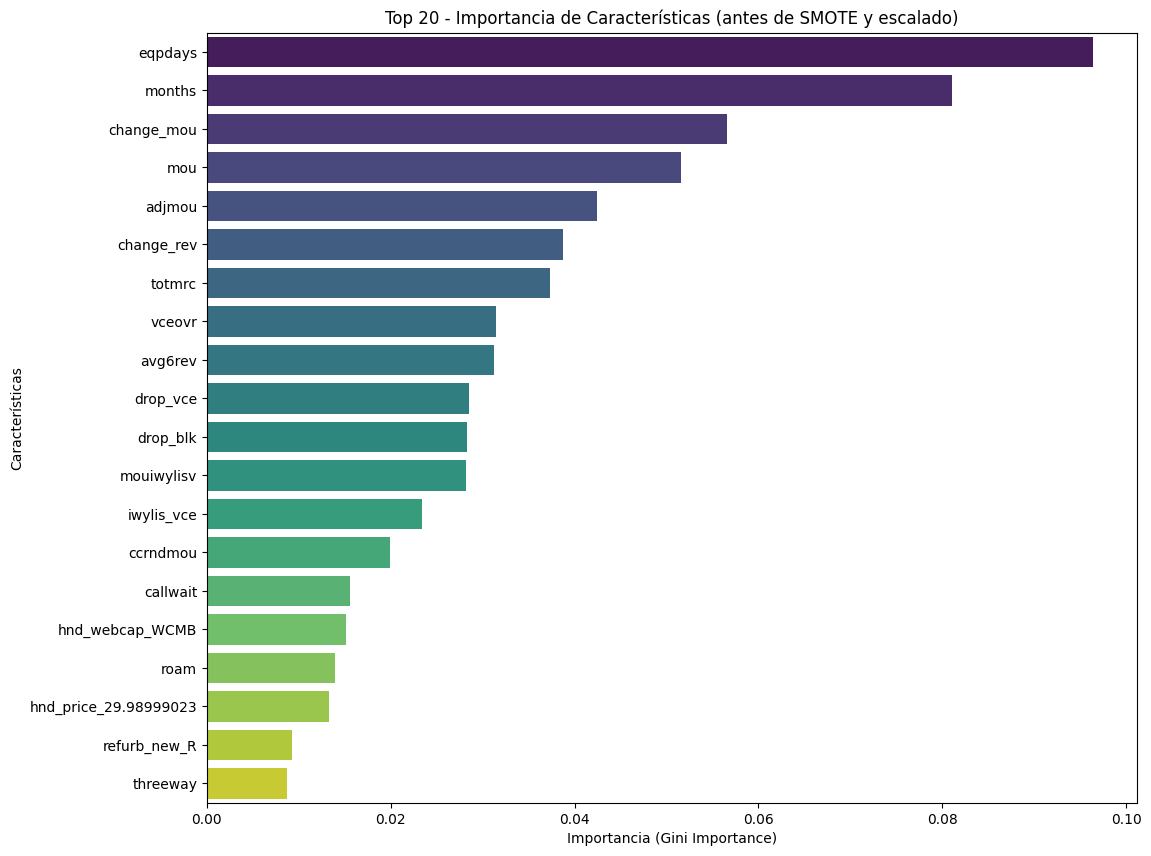

In [101]:
print("--- FEATURE IMPORTANCE ANTES DE SMOTE Y EL ESCALADO---")
print(f"Entrenando RandomForest en un dataset de shape: {X_train_encoded.shape}")

# Usamos parámetros básicos para una evaluación rápida de la importancia
feature_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
feature_model.fit(X_train_encoded, y_train)

# --- Extraer y visualizar las características más importantes ---
importances = pd.Series(feature_model.feature_importances_, index=X_train_encoded.columns)

# Ordenar la serie de mayor a menor y seleccionar las 20 primeras
top_20_features = importances.sort_values(ascending=False).head(20)

print("\nLas 20 características más importantes:")
print(top_20_features)


# --- Graficar las características más importantes ---
plt.figure(figsize=(12, 10))
plt.title("Top 20 - Importancia de Características (antes de SMOTE y escalado)")
ax = sns.barplot(y=top_20_features.index, x=top_20_features.values, palette="viridis", orient='h')
ax.set_xlabel("Importancia (Gini Importance)")
ax.set_ylabel("Características")
plt.show()

# --- (Opcional) Crear una nueva lista de columnas a mantener ---
# Si quisieras reducir tu dataset a solo estas características, podrías descomentar las siguientes líneas
# antes de pasar al Paso 6.
#
# top_features_list = top_20_features.index.tolist()
# X_train_encoded = X_train_encoded[top_features_list]
# X_test_encoded = X_test_encoded[top_features_list]
# X_predict_encoded = X_predict_encoded[top_features_list]
# print(f"\nDataset reducido a las {len(top_features_list)} características más importantes.")



Despues del OHE rebalanzeamos el modelo usando SMOTE, la ventaja de usar SMOTE respecto al undersampler es que no perdemos tanta información.

**SMOTE (Synthetic Minority Over-sampling Technique)** crea muestras sintéticas de la clase minoritaria (en este caso, 'churn' = 1), logrando un balance sin perder datos.

El orden correcto de transformaciones del train despues del one hot encoding: Escalar, Aplicar el filtro de baja varianza, y luego el Smote.

In [102]:
# PASO 6: ESCALADO, BAJA VARIANZA Y SMOTE (EN EL ORDEN CORRECTO)
print("--- PASO 6: Aplicando Escalado, Selección de Varianza y SMOTE ---")
scaler = StandardScaler()
selector = VarianceThreshold(threshold=0.01)#Ponemos un umbral bajo para eliminar columnas con varianza del 1% o menos
smote = SMOTE(random_state=42)# SMOTE para rebalancear el conjunto de entrenamiento

# 1. Escalar (Ajustar en train, transformar todos)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=train_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=train_cols, index=X_test.index)
X_predict_scaled = pd.DataFrame(scaler.transform(X_predict_encoded), columns=train_cols, index=X_predict.index)

# 2. Selección de Varianza (Ajustar en train escalado, transformar todos)
selector.fit(X_train_scaled)
final_columns = X_train_scaled.columns[selector.get_support()]

X_train_filtered = X_train_scaled[final_columns]
X_test_filtered = X_test_scaled[final_columns]
X_predict_filtered = X_predict_scaled[final_columns]

print(f"Se eliminaron {X_train_scaled.shape[1] - X_train_filtered.shape[1]} columnas de baja varianza.")

# 3. Rebalanceo (SMOTE) - Aplicar SOLO al conjunto de entrenamiento ya procesado
X_train_final, y_train_resampled = smote.fit_resample(X_train_filtered, y_train)

print("\nRebalanceo completado.")
print("Distribución de clases en train después de SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# 4. DataFrames Finales para el modelo
X_test_final = X_test_filtered
X_predict_final = X_predict_filtered

print(f"\nDimensiones finales - Train: {X_train_final.shape}")
print(f"Dimensiones finales - Test: {X_test_final.shape}")
print(f"Dimensiones finales - Predict: {X_predict_final.shape}\n")
print(" Pipeline de preprocesamiento finalizado sin DATA LEAKAGE")

--- PASO 6: Aplicando Escalado, Selección de Varianza y SMOTE ---
Se eliminaron 0 columnas de baja varianza.

Rebalanceo completado.
Distribución de clases en train después de SMOTE:
churn
1    19216
0    19216
Name: count, dtype: int64

Dimensiones finales - Train: (38432, 119)
Dimensiones finales - Test: (15000, 119)
Dimensiones finales - Predict: (1475, 119)

 Pipeline de preprocesamiento finalizado sin DATA LEAKAGE


# Modelado

## Feature importance

Entrenando RandomForest en un dataset de shape: (38432, 119)

Las 10 características más importantes:
eqpdays                  0.184032
months                   0.154474
hnd_webcap_WCMB          0.057226
change_mou               0.046103
hnd_price_29.98999023    0.044504
totmrc                   0.041135
mou                      0.034905
vceovr                   0.030198
adjmou                   0.025842
asl_flag_Y               0.023285
dtype: float64


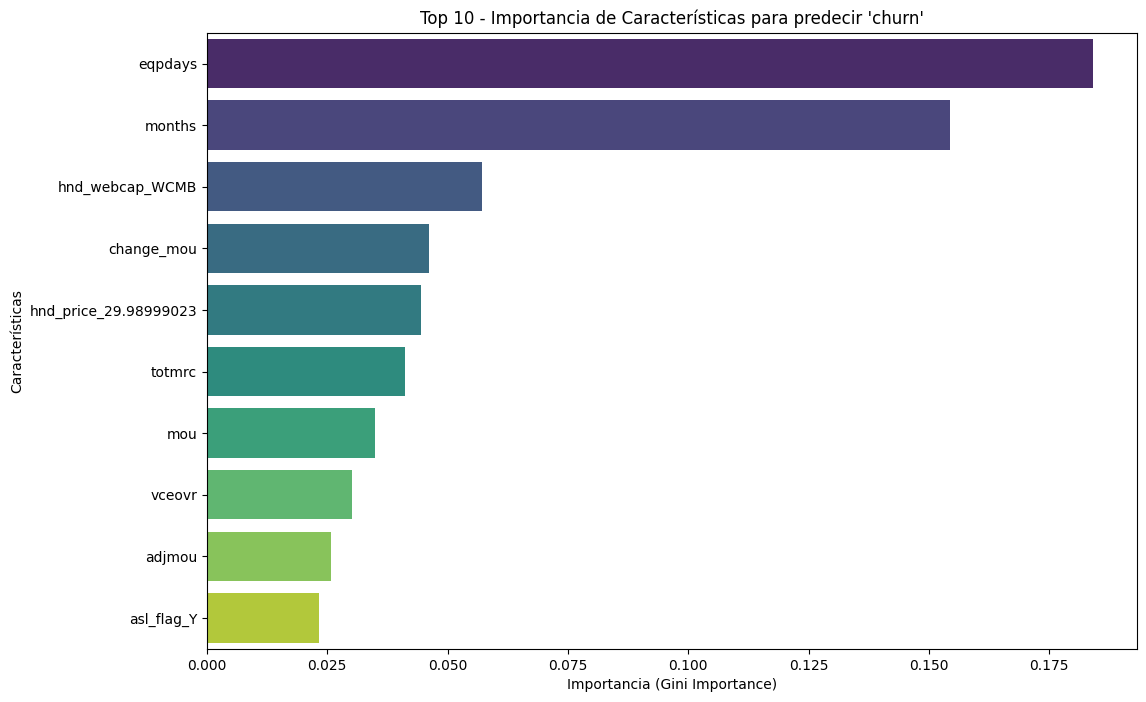

In [103]:
# --- Entrenar el RandomForest Classifier ---
# Probamos con los siguientes parametros
params = {'random_state': 42, 'n_jobs': 4, 'n_estimators': 100, 'max_depth': 8} 

print(f"Entrenando RandomForest en un dataset de shape: {X_train_final.shape}")

clf = RandomForestClassifier(**params)# se usa ** porque estamos desempaquetando un diccionario/JSON
clf = clf.fit(X_train_final, y_train_resampled)

# --- 3. Calcular, ordenar y seleccionar las características más importantes ---
# Crea una Serie de Pandas con las importancias, usando los nombres de las columnas como índice
importances = pd.Series(clf.feature_importances_, index=X_train_final.columns)

# Ordena la serie de mayor a menor y selecciona las 10 primeras
top_10_features = importances.sort_values(ascending=False).head(10)

print("\nLas 10 características más importantes:")
print(top_10_features)


# --- 4. Plotea las 10 mejores características ---
plt.figure(figsize=(12, 8))
plt.title(f"Top 10 - Importancia de Características para predecir '{target}'")
ax = sns.barplot(y=top_10_features.index, x=top_10_features.values, palette="viridis", orient='h')
ax.set_xlabel("Importancia (Gini Importance)")
ax.set_ylabel("Características")
plt.show()

## Split train-test 


Paso realizado anteriormente (para evitar el data leakage).

## Rebalanceo del train

Este paso se ha hecho anteriormente con el SMOTE y el filtro de la baja varianza.

## Estandarización

Se ha realizado en un paso anterior

### Comprobación de que tenemos las mismas variables en predict y en train

Aunque con el OHE este paso no haría falta.

In [104]:
col_df_pred = X_predict_final.columns    
col_df_pred

col_df = X_train_final.columns
col_df

Index(['mou', 'totmrc', 'vceovr', 'roam', 'change_mou', 'change_rev',
       'drop_vce', 'blck_dat', 'ccrndmou', 'threeway',
       ...
       'ethnic_Other', 'ethnic_S', 'ethnic_U', 'ethnic_Z', 'kid0_2_Y',
       'kid3_5_Y', 'kid6_10_Y', 'kid11_15_Y', 'kid16_17_Y', 'creditcd_Y'],
      dtype='object', length=119)

In [105]:
# columnas que están en el dataset de entrenamiento pero no están en el dataset de predicción

col_faltantes = []
for col in col_df:
  if col not in col_df_pred:
    col_faltantes.append(col)
col_faltantes

[]

In [106]:
# columnas que están en el dataset de predicción pero no en el dataset de entrenamiento (nueva categoría)

col_sobrantes = []
for col in col_df_pred:
  if col not in col_df:
    col_sobrantes.append(col)
col_sobrantes

[]

In [107]:
# verificamos que los dataset tienen el mismo número de variables

X_predict_final.shape[1] == X_train_final.shape[1]

True

## Competición de modelos


Competir sobre el f1_score

In [108]:
# añadimos en una lista los modelos que queremos poner a competir

modelos = []

modelos.append(('LogisticRegression', LogisticRegression(random_state=42)))
modelos.append(('RidgeClassifier', RidgeClassifier(random_state=42)))
modelos.append(('DecisionTreeClassifier', DecisionTreeClassifier(random_state=42)))
#modelos.append(('RandomForestClassifier', RandomForestClassifier(random_state=42)))
modelos.append(('GradientBoostingClassifier', GradientBoostingClassifier(random_state=42)))
modelos.append(('XGBClassifier', XGBClassifier(random_state=42, verbosity=0)))
modelos.append(('CatBoostClassifier', CatBoostClassifier(verbose=False, random_seed=42)))

In [109]:
metricas_modelos = pd.DataFrame(columns=['modelo', 'f1_score','AUC'])

In [110]:
def curva_auc(y_t, y_p):
  """imprime la curva ROC y el AUC"""

  # calculate the fpr and tpr for all thresholds of the classification
  fpr, tpr, threshold = metrics.roc_curve(y_t, y_p)
  roc_auc = metrics.auc(fpr, tpr)

  # para añadir el gráfico
  plt.figure(figsize=(4, 3))
  plt.title('Receiver Operating Characteristic')
  plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
  plt.legend(loc = 'lower right')
  plt.plot([0, 1], [0, 1],'r--')
  plt.xlim([0, 1])
  plt.ylim([0, 1])
  plt.ylabel('True Positive Rate')
  plt.xlabel('False Positive Rate')
  plt.show()

Entrenando y evaluando modelo: LogisticRegression
LogisticRegression -> AUC: 0.7992, Mejor F1-score: 0.7126 (umbral: 0.43)


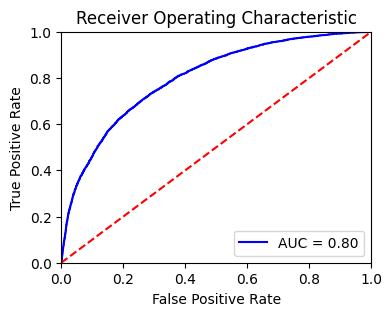

--------------------------------------------------
Entrenando y evaluando modelo: RidgeClassifier
RidgeClassifier -> AUC: 0.7979, Mejor F1-score: 0.6812 (umbral: 0.10)


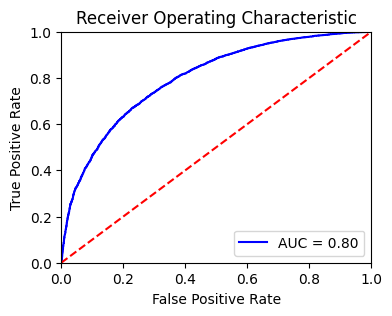

--------------------------------------------------
Entrenando y evaluando modelo: DecisionTreeClassifier
DecisionTreeClassifier -> AUC: 0.7354, Mejor F1-score: 0.7114 (umbral: 0.10)


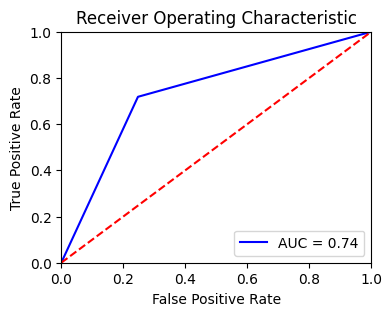

--------------------------------------------------
Entrenando y evaluando modelo: GradientBoostingClassifier
GradientBoostingClassifier -> AUC: 0.8938, Mejor F1-score: 0.7916 (umbral: 0.46)


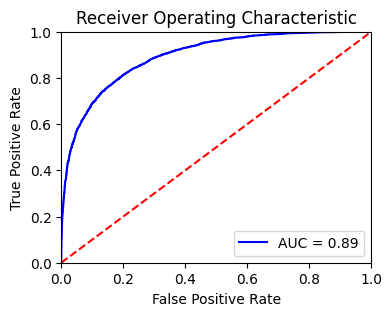

--------------------------------------------------
Entrenando y evaluando modelo: XGBClassifier
XGBClassifier -> AUC: 0.9337, Mejor F1-score: 0.8379 (umbral: 0.40)


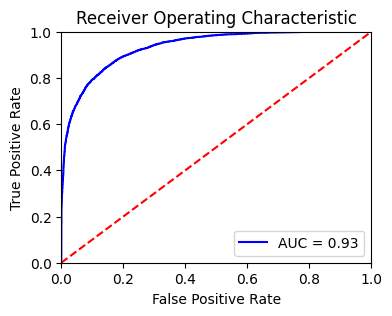

--------------------------------------------------
Entrenando y evaluando modelo: CatBoostClassifier
CatBoostClassifier -> AUC: 0.9383, Mejor F1-score: 0.8443 (umbral: 0.43)


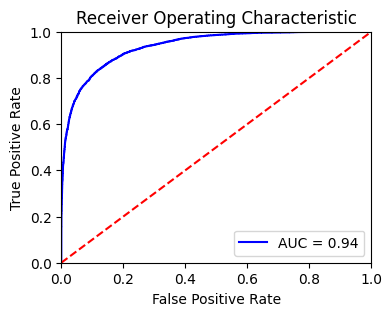

--------------------------------------------------


In [111]:
# (La definición de curva_auc y la lista de modelos se mantienen igual)
metricas_modelos = pd.DataFrame(columns=['modelo', 'f1_score', 'AUC', 'mejor_threshold'])

for nombre, modelo in modelos:
    print(f"Entrenando y evaluando modelo: {nombre}")

    # Entrenamiento con el set de train FINAL
    modelo.fit(X_train_final, y_train_resampled)

    # Obtener puntuaciones sobre el set de TEST
    if hasattr(modelo, "predict_proba"):
        y_scores = modelo.predict_proba(X_test_final)[:, 1]
    else: # Para Ridge, que usa decision_function
        y_scores = modelo.decision_function(X_test_final)
    
    # Calcular AUC sobre el set de TEST
    auc = metrics.roc_auc_score(y_test, y_scores)

    # Buscar mejor F1-score en el set de TEST
    thresholds = np.linspace(0.1, 0.9, 100)
    f1_scores = [metrics.f1_score(y_test, (y_scores >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # Guardar y mostrar resultados
    nueva_fila = pd.DataFrame({
        'modelo': [nombre], 'f1_score': [best_f1], 'AUC': [auc], 'mejor_threshold': [best_threshold]
    })
    metricas_modelos = pd.concat([metricas_modelos, nueva_fila], ignore_index=True)

    print(f"{nombre} -> AUC: {auc:.4f}, Mejor F1-score: {best_f1:.4f} (umbral: {best_threshold:.2f})")
    curva_auc(y_test, y_scores)
    print(50*'-')

## Hiperparametrización

In [53]:
# modelo = CatBoostClassifier(verbose=0, random_seed=42)

In [54]:
# parameters = {
#     'iterations': [100, 500, 1000],                 # Número de árboles
#     'depth': [4, 6, 8, 10],                         # Profundidad de los árboles
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],        # Tasa de aprendizaje
# }

In [55]:
# grid_search = GridSearchCV(modelo,
#                           parameters,
#                           cv=2,
#                           verbose=True)

# grid_search.fit(X_train_final, y_train_resampled)

In [56]:
# # se imprime el modelo con los mejores parametros
# grid_search.best_params_

Planteamos 2 Alternativas al gridsearch que este último tarda mucho ya que hay que entrenar a 96 modelos...


Probamos con RandomizedSearchCV:

In [57]:
 # Alternativa 1: RandomizedSearchCV

# print("--- Ejecutando RandomizedSearchCV ---")

# # Definimos el espacio de búsqueda. Para tasas de aprendizaje, es mejor usar una distribución uniforme.
# parameters_random = {
#     'iterations': [500, 1000, 1500],
#     'depth': randint(4, 11),  # Un entero aleatorio entre 4 y 10
#     'learning_rate': uniform(0.01, 0.2), # Un float aleatorio entre 0.01 y 0.21
#     'l2_leaf_reg': uniform(1, 10) # Parámetro de regularización
# }

# # Usamos StratifiedKFold para la validación cruzada, es mejor para clasificación
# cv_stratified = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# # n_iter controla cuántas combinaciones aleatorias probar. 10-20 es un buen punto de partida.
# random_search = RandomizedSearchCV(
#     CatBoostClassifier(verbose=0, random_seed=42),
#     param_distributions=parameters_random,
#     n_iter=15, # Probar 15 combinaciones aleatorias
#     cv=cv_stratified,
#     scoring='f1', # Optimizar para F1-score
#     verbose=1,
#     n_jobs=-1, # Usar todos los cores de la CPU
#     random_state=42
# )

# random_search.fit(X_train_final, y_train_resampled)

# print("\nMejores parámetros encontrados con RandomizedSearchCV:")
# print(random_search.best_params_)
# print(f"Mejor F1-score en CV: {random_search.best_score_:.4f}")



Probamos con Optuna que tarda menos (solo 25 iteraciones):

In [112]:

# Alternativa 2: Optuna (Recomendada por Gemini)


print("\n\n--- Ejecutando Optuna ---")

# 1. Definir la función "objetivo" que Optuna intentará maximizar
def objective(trial):
    # Definimos el espacio de búsqueda de hiperparámetros
    params = {
        'objective': 'Logloss',
        'eval_metric': 'F1',
        'verbose': 0,
        'random_seed': 42,
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli']),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0) if trial.params['bootstrap_type'] == 'Bernoulli' else None
    }

    model = CatBoostClassifier(**params)
    
    # Entrenar y evaluar el modelo. Usamos F1-score como métrica a maximizar.
    # Optuna puede integrarse con validación cruzada, pero para un ejemplo rápido,
    # podemos usar un set de validación simple.
    # Aquí lo haremos con el F1-score sobre el set de test para simplificar.
    # En un caso real, se usaría validación cruzada dentro de la función objetivo.
    model.fit(X_train_final, y_train_resampled)
    preds = model.predict(X_test_final)
    f1 = f1_score(y_test, preds)
    
    return f1

# 2. Crear un "estudio" y ejecutar la optimización
# direction="maximize" porque queremos el F1-score más alto posible.
study = optuna.create_study(direction="maximize")

# n_trials controla cuántas veces se ejecutará la función objetivo.
# 20-30 pruebas suelen dar muy buenos resultados.
study.optimize(objective, n_trials=25)


# 3. Mostrar los resultados
print("\nMejores parámetros encontrados con Optuna:")
print(study.best_trial.params)
print(f"Mejor F1-score: {study.best_value:.4f}")


[I 2025-07-07 11:46:18,703] A new study created in memory with name: no-name-e966afb3-0ca0-4156-b5d3-5bfe1b95f1b2




--- Ejecutando Optuna ---


[I 2025-07-07 11:46:30,398] Trial 0 finished with value: 0.8408665017614871 and parameters: {'iterations': 520, 'depth': 5, 'learning_rate': 0.19994822349555746, 'l2_leaf_reg': 1.2890206420245356, 'bootstrap_type': 'Bayesian'}. Best is trial 0 with value: 0.8408665017614871.
[I 2025-07-07 11:46:49,665] Trial 1 finished with value: 0.8455528846153846 and parameters: {'iterations': 743, 'depth': 6, 'learning_rate': 0.14748962795038714, 'l2_leaf_reg': 2.408233389685661, 'bootstrap_type': 'Bernoulli', 'subsample': 0.6056941069233226}. Best is trial 1 with value: 0.8455528846153846.
[I 2025-07-07 11:47:50,057] Trial 2 finished with value: 0.847682119205298 and parameters: {'iterations': 1727, 'depth': 7, 'learning_rate': 0.12601098099423755, 'l2_leaf_reg': 5.86316601358115, 'bootstrap_type': 'Bernoulli', 'subsample': 0.7859318058249436}. Best is trial 2 with value: 0.847682119205298.
[I 2025-07-07 11:48:35,146] Trial 3 finished with value: 0.847940074906367 and parameters: {'iterations': 15


Mejores parámetros encontrados con Optuna:
{'iterations': 1872, 'depth': 6, 'learning_rate': 0.14335730778973552, 'l2_leaf_reg': 8.91117027013617, 'bootstrap_type': 'Bayesian'}
Mejor F1-score: 0.8511


Mejores parámetros encontrados con Optuna:
{'iterations': 1872, 'depth': 6, 'learning_rate': 0.14335730778973552, 'l2_leaf_reg': 8.91117027013617, 'bootstrap_type': 'Bayesian'}

## Entrenamiento del modelo final

In [113]:
# DEFINIR EL MODELO FINAL CON LOS MEJORES HIPERPARÁMETROS
print("--- Paso 1: Configurando el modelo final con los mejores parámetros de Optuna ---")

# Extrae los mejores parámetros encontrados por Optuna
best_params={'iterations': 1872, 'depth': 6, 'learning_rate': 0.14335730778973552, 'l2_leaf_reg': 8.91117027013617, 'bootstrap_type': 'Bayesian'}
# Si usaste RandomizedSearchCV, descomenta la siguiente línea en su lugar:
# best_params = random_search.best_params_

# Añadimos parámetros fijos que no se optimizaron pero son importantes
best_params['random_seed'] = 42
best_params['verbose'] = 0

# Instanciamos el modelo final
final_model = CatBoostClassifier(**best_params)

# PASO 2: ENTRENAR EL MODELO FINAL
print("\n--- Paso 2: Entrenando el modelo final con TODOS los datos de entrenamiento... ---")
# Entrenamos el modelo con el conjunto de entrenamiento completo (ya procesado y rebalanceado)
final_model.fit(X_train_final, y_train_resampled)
print("Modelo final entrenado.")




# PASO 3: EVALUACIÓN FINAL Y BÚSQUEDA DEL MEJOR UMBRAL EN EL TEST SET

print("\n--- Paso 3: Evaluando en el Test Set y encontrando el mejor umbral ---")

# 1. Obtener las probabilidades en el conjunto de test
y_scores_test = final_model.predict_proba(X_test_final)[:, 1]

# 2. Calcular métricas finales (AUC y F1-Score con umbral por defecto de 0.5)
final_auc = metrics.roc_auc_score(y_test, y_scores_test)
final_f1_default = metrics.f1_score(y_test, (y_scores_test >= 0.5).astype(int))
print(f"AUC final en Test Set: {final_auc:.4f}")
print(f"F1-Score final (umbral 0.5) en Test Set: {final_f1_default:.4f}")

# 3. Encontrar el umbral que maximiza el F1-Score
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = [metrics.f1_score(y_test, (y_scores_test >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_score = f1_scores[best_idx]

print(f"\nMejor F1-Score posible en Test Set: {best_f1_score:.4f}")
print(f"Umbral óptimo para maximizar F1-Score: {best_threshold:.3f}")




--- Paso 1: Configurando el modelo final con los mejores parámetros de Optuna ---

--- Paso 2: Entrenando el modelo final con TODOS los datos de entrenamiento... ---
Modelo final entrenado.

--- Paso 3: Evaluando en el Test Set y encontrando el mejor umbral ---
AUC final en Test Set: 0.9433
F1-Score final (umbral 0.5) en Test Set: 0.8511

Mejor F1-Score posible en Test Set: 0.8527
Umbral óptimo para maximizar F1-Score: 0.472


In [115]:
# predict
predict_test = pd.DataFrame(final_model.predict(X_test_final), columns=["churn"])
predict_test



,churn
0,0
1,0
2,1
3,0
4,0
...,...
14995,0
14996,0
14997,0
14998,1


In [116]:
# predict_proba
predict_proba_test= pd.DataFrame(final_model.predict_proba(X_test_final)[:, 1], columns=["proba_churn"])
predict_proba_test

,proba_churn
0,0.005729
1,0.000285
2,0.691071
3,0.413969
4,0.114217
...,...
14995,0.062452
14996,0.180080
14997,0.012407
14998,0.926869


# Evalucación del modelo final

## AUC

Calcular el AUC con el predict_proba

In [117]:
# Calcular métricas finales (AUC y F1-Score con umbral por defecto de 0.5)
final_auc = metrics.roc_auc_score(y_test, y_scores_test)

print(f"AUC final en Test Set: {final_auc:.4f}")


AUC final en Test Set: 0.9433


## matriz de confusión


--- Paso 3.5: Generando la Matriz de Confusión para el Test Set ---


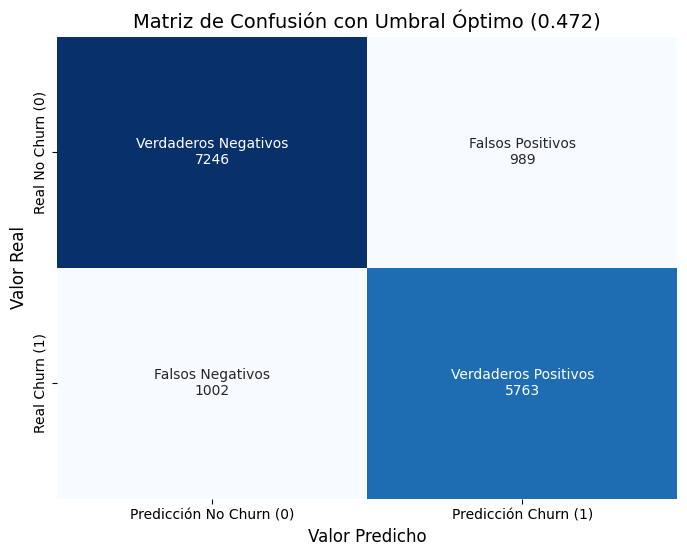


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

No Churn (0)       0.88      0.88      0.88      8235
   Churn (1)       0.85      0.85      0.85      6765

    accuracy                           0.87     15000
   macro avg       0.87      0.87      0.87     15000
weighted avg       0.87      0.87      0.87     15000



In [118]:
# PASO 3.5: VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
print("\n--- Paso 3.5: Generando la Matriz de Confusión para el Test Set ---")

# 1. Obtenemos las predicciones de clase usando el umbral óptimo que encontramos
y_pred_test_optimal = (y_scores_test >= best_threshold).astype(int)

# 2. Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred_test_optimal)

# 3. Extraemos los valores para una mejor anotación en el gráfico
# (Verdaderos Negativos, Falsos Positivos, Falsos Negativos, Verdaderos Positivos)
tn, fp, fn, tp = cm.ravel()

# 4. Creamos las etiquetas para el gráfico
labels = [
    f'Verdaderos Negativos\n{tn}', 
    f'Falsos Positivos\n{fp}',
    f'Falsos Negativos\n{fn}',
    f'Verdaderos Positivos\n{tp}'
]
labels = np.asarray(labels).reshape(2,2)

# 5. Creamos la visualización con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicción No Churn (0)', 'Predicción Churn (1)'],
            yticklabels=['Real No Churn (0)', 'Real Churn (1)'])
plt.title(f'Matriz de Confusión con Umbral Óptimo ({best_threshold:.3f})', fontsize=14)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Predicho', fontsize=12)
plt.show()

# 6.Imprimir el reporte de clasificación
print("\nReporte de Clasificación Detallado:")
print(metrics.classification_report(y_test, y_pred_test_optimal, target_names=['No Churn (0)', 'Churn (1)']))

## f1_score

In [119]:
final_f1_default = metrics.f1_score(y_test, (y_scores_test >= 0.5).astype(int))
print(f"F1-Score final (umbral 0.5) en Test Set: {final_f1_default:.4f}")

F1-Score final (umbral 0.5) en Test Set: 0.8511


# Guardar modelo

Guardar el modelo y lo que sea necesario para ejecutarlo (scaler)

In [120]:
# Importar la librería para guardar y cargar objetos
print("--- Guardando los componentes del pipeline del modelo ---")

# 1. Crear una carpeta para guardar los artefactos del modelo si no existe
output_dir = 'modelo_churn'
os.makedirs(output_dir, exist_ok=True)

# 2. Definir las rutas de los archivos
model_path = os.path.join(output_dir, 'catboost_model.joblib')
encoder_path = os.path.join(output_dir, 'onehot_encoder.joblib')
scaler_path = os.path.join(output_dir, 'standard_scaler.joblib')
selector_path = os.path.join(output_dir, 'variance_selector.joblib')
columns_path = os.path.join(output_dir, 'final_columns.joblib')

# 3. Guardar cada objeto en su propio archivo .joblib
#    - final_model: El modelo CatBoost ya entrenado.
#    - encoder: El OneHotEncoder ajustado con las categorías de train.
#    - scaler: El StandardScaler ajustado con las medias/desviaciones de train.
#    - selector: El VarianceThreshold ajustado para saber qué columnas eliminar.
#    - final_columns: La lista con el nombre y orden de las columnas finales.

joblib.dump(final_model, model_path)
joblib.dump(encoder, encoder_path)
joblib.dump(scaler, scaler_path)
joblib.dump(selector, selector_path)
joblib.dump(final_columns, columns_path)

print(f"Modelo y componentes guardados en la carpeta: '{output_dir}'")


# EJEMPLO: CÓMO CARGAR LOS COMPONENTES PARA HACER UNA NUEVA PREDICCIÓN
print("\n--- Ejemplo de cómo cargar los objetos para una nueva predicción ---")

# En un nuevo script o notebook, cargarías los objetos así:
loaded_model = joblib.load(model_path)
loaded_encoder = joblib.load(encoder_path)
loaded_scaler = joblib.load(scaler_path)
loaded_selector = joblib.load(selector_path)
loaded_columns = joblib.load(columns_path)

print(" Todos los componentes se han cargado correctamente en memoria.")

# Ahora podrías tomar datos nuevos (new_data_df), aplicarles las mismas transformaciones
# usando los objetos cargados (loaded_encoder.transform, loaded_scaler.transform, etc.)
# y finalmente hacer la predicción con loaded_model.predict_proba().



--- Guardando los componentes del pipeline del modelo ---
Modelo y componentes guardados en la carpeta: 'modelo_churn'

--- Ejemplo de cómo cargar los objetos para una nueva predicción ---
✅ Todos los componentes se han cargado correctamente en memoria.


# Interpretabilidad

## Modelo lineal

Si el mejor modelo ha sido un algoritmo basado en arbole de decisión, entrenamos el mejor modelo lineal de la competición de modelos, sin hiperparametrizar

Imprimir los coeficientes por variable + intercept

In [121]:

# PASO 1: ENTRENAR EL MEJOR MODELO LINEAL
print("--- Entrenando el modelo de Regresión Logística para interpretabilidad ---")

# Instanciamos el modelo. Usamos parámetros por defecto como se pide.
# Aumentar max_iter puede ser necesario si el modelo no converge.
linear_model = LogisticRegression(random_state=42, max_iter=1000)

# Entrenamos con los datos finales (escalados, rebalanceados, etc.)
linear_model.fit(X_train_final, y_train_resampled)

print(" Modelo entrenado.")



# PASO 2: EXTRAER Y MOSTRAR LOS COEFICIENTES
print("\n--- Extrayendo coeficientes del modelo ---")

# 1. Extraer el intercepto (el sesgo del modelo)
intercept = linear_model.intercept_[0]
print(f"\nIntercepto (Sesgo) del modelo: {intercept:.4f}")

# 2. Extraer los coeficientes de las variables
#    Los coeficientes están en un array 2D, por eso seleccionamos la primera (y única) fila [0]
coefficients = linear_model.coef_[0]

# 3. Crear un DataFrame para asociar cada coeficiente con su variable
coef_df = pd.DataFrame({
    'Variable': final_columns, # Usamos las columnas del DataFrame final
    'Coeficiente': coefficients
})

# 4. Añadir una columna con el valor absoluto para ordenar por impacto
coef_df['Impacto (Absoluto)'] = np.abs(coef_df['Coeficiente'])

# 5. Ordenar el DataFrame por el impacto de mayor a menor
coef_df_sorted = coef_df.sort_values(by='Impacto (Absoluto)', ascending=False)

print("\nCoeficientes de todas las variables (ordenados por impacto):")
# Mostramos todas las filas para una revisión completa
with pd.option_context('display.max_rows', None):
    print(coef_df_sorted)



--- Entrenando el modelo de Regresión Logística para interpretabilidad ---
 Modelo entrenado.

--- Extrayendo coeficientes del modelo ---

Intercepto (Sesgo) del modelo: -0.1092

Coeficientes de todas las variables (ordenados por impacto):
                               Variable  Coeficiente  Impacto (Absoluto)
16                               months    -0.879437            0.879437
0                                   mou    -0.874153            0.874153
19                              eqpdays     0.838803            0.838803
17                               adjmou     0.582625            0.582625
2                                vceovr     0.525442            0.525442
4                            change_mou    -0.398636            0.398636
56                         refurb_new_R     0.312830            0.312830
5                            change_rev     0.312653            0.312653
30                          crclscod_EA    -0.278332            0.278332
73                      hnd_we

Imprimir los coeficientes de las 10 variables con mayor impacto (positivo o negativo)


--- Visualizando las 10 variables con mayor impacto ---


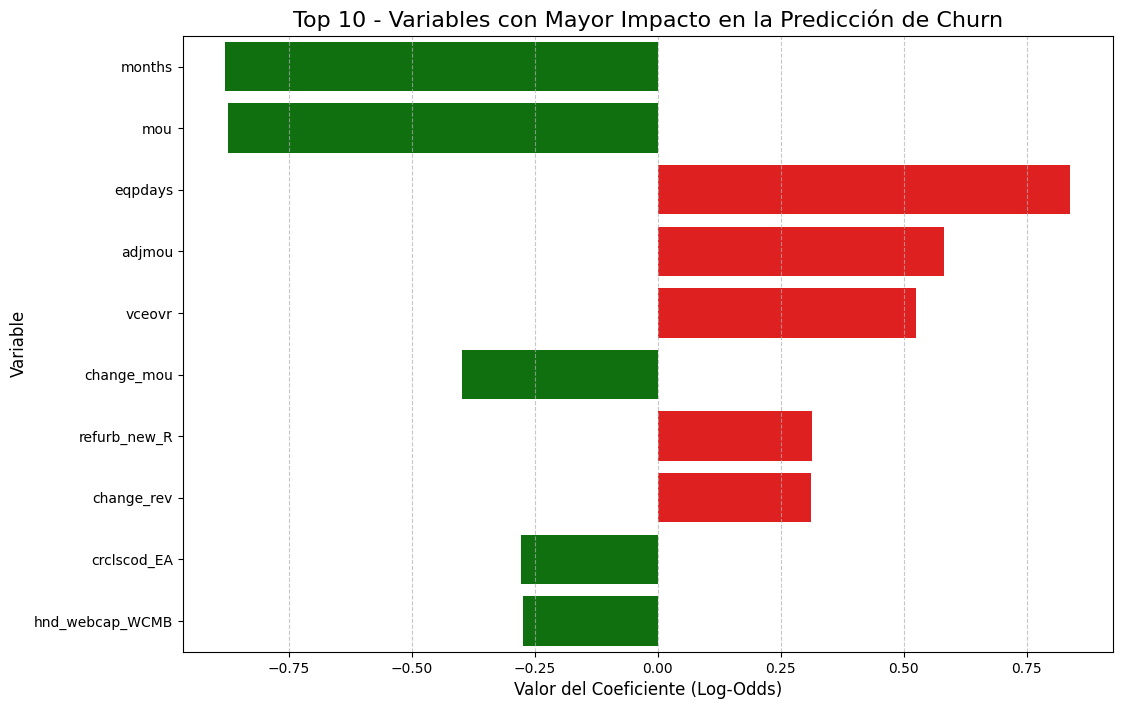

In [122]:
# PASO 3: VISUALIZAR LAS 10 VARIABLES MÁS IMPORTANTES
print("\n--- Visualizando las 10 variables con mayor impacto ---")

# 1. Seleccionar las 10 variables con mayor impacto
top_10_features = coef_df_sorted.head(10)

# 2. Crear una paleta de colores para impacto positivo (aumenta churn) y negativo (reduce churn)
palette = ['red' if c > 0 else 'green' for c in top_10_features['Coeficiente']]

# 3. Crear el gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Variable', data=top_10_features, palette=palette, orient='h')

plt.title('Top 10 - Variables con Mayor Impacto en la Predicción de Churn', fontsize=16)
plt.xlabel('Valor del Coeficiente (Log-Odds)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



En el caso del modelo lineal las top 5 variables con mayor impacto son:
- **mou (media de minutos/mes de uso)**: esto mide como de asiduo es el usuario, que es proporcional en lealtad del cliente.
- **months (meses en servicio)**:La antigüedad del cliente es un factor clave. Clientes más nuevos tienen una menor lealtad y es más probable que se vayan si no están satisfechos, mientras que los clientes más antiguos suelen ser más fieles.
- **eqpdays (Días con el equipo actual)**: La antigüedad del teléfono móvil es un factor muy relevante. Un cliente con un móvil antiguo es un candidato perfecto para aceptar una oferta de la competencia que incluya un terminal nuevo y moderno. 
- **adjmou** (Facturación ajustada al total de minutos de uso durante la vida del cliente): Es una métrica indicadora de lo cara que es la oferta para el cliente. A más cara más probabilidad de que el cliente se vaya.
- **vceovr** (Ingresos medios por voz): Lo que ingresa la compañia por minuto de llamada de voz del cliente, es directamente proporcional con el abandono del cliente.

## Modelo de árbol de decisión

Si el mejor modelo ha sido un modelo lineal, entrenamos el mejor modelo basado en arboles de decisión, sin hiperparametrizar

&#x26a0;&#xfe0f;
El shap necesita el nombres de las variables. Estandarizar los datos los quita

### Shap values

In [123]:
# PASO 1: ENTRENAR UN MODELO DE ÁRBOL PARA INTERPRETABILIDAD
print("--- Entrenando un modelo CatBoost para el análisis con SHAP ---")

# Como se pide, entrenamos un modelo basado en árboles sin hiperparametrizar.
# Usamos los datos finales (escalados, rebalanceados, etc.)
interpret_model = CatBoostClassifier(verbose=0, random_state=42)
interpret_model.fit(X_train_final, y_train_resampled)

print("Modelo para interpretabilidad entrenado.")



--- Entrenando un modelo CatBoost para el análisis con SHAP ---
Modelo para interpretabilidad entrenado.


In [124]:
# PASO 2: CALCULAR LOS VALORES SHAP
print("\n--- Calculando los valores SHAP en el conjunto de test... ---")

# 1. Crear un explicador de SHAP para modelos de árbol.
#    Le pasamos el modelo que acabamos de entrenar.
explainer = shap.TreeExplainer(interpret_model)

# 2. Calcular los valores SHAP.
#    Se calculan sobre el conjunto de test final (escalado y filtrado).
#    shap_values es una array en este caso asi que lo usamos directamente
shap_values = explainer.shap_values(X_test_final)
print(f"Tipo de shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Longitud de la lista shap_values: {len(shap_values)}")
    print(f"Shape shap_values[0]: {np.array(shap_values[0]).shape}")
else:
    print(f"Shape shap_values: {np.array(shap_values).shape}")
print(f"Shape X_test_final: {X_test_final.shape}")

print(" Valores SHAP calculados.")



--- Calculando los valores SHAP en el conjunto de test... ---
Tipo de shap_values: <class 'numpy.ndarray'>
Shape shap_values: (15000, 119)
Shape X_test_final: (15000, 119)
 Valores SHAP calculados.


In [125]:
X_test_final

,mou,totmrc,vceovr,roam,change_mou,change_rev,drop_vce,blck_dat,ccrndmou,threeway,iwylis_vce,mouiwylisv,peak_dat,mou_opkd,drop_blk,callwait,months,adjmou,avg6rev,eqpdays,uniqsubs_2,uniqsubs_3,uniqsubs_Other,actvsubs_2,actvsubs_3,actvsubs_Other,crclscod_AA,crclscod_B,crclscod_BA,crclscod_CA,crclscod_EA,crclscod_Other,asl_flag_Y,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,prizm_social_one_Unknown,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_HOUSTON AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_Other,area_SOUTHWEST AREA,dualband_T,dualband_Y,refurb_new_R,hnd_price_149.9899902,hnd_price_199.9899902,hnd_price_29.98999023,hnd_price_59.98999023,hnd_price_79.98999023,hnd_price_9.989997864,hnd_price_99.98999023,hnd_price_Other,phones_2.0,phones_3.0,phones_4.0,phones_Other,models_2.0,models_3.0,models_Other,hnd_webcap_WC,hnd_webcap_WCMB,truck_1.0,rv_1.0,ownrent_R,ownrent_Unknown,lor_15.0,lor_2.0,lor_3.0,lor_4.0,lor_5.0,lor_6.0,lor_7.0,lor_Other,lor_Unknown,marital_B,marital_M,marital_S,marital_U,infobase_NM,income_1.0,income_2.0,income_3.0,income_4.0,income_5.0,income_6.0,income_7.0,income_8.0,income_9.0,numbcars_1.0,numbcars_2.0,numbcars_3.0,forgntvl_1.0,ethnic_H,ethnic_I,ethnic_N,ethnic_O,ethnic_Other,ethnic_S,ethnic_U,ethnic_Z,kid0_2_Y,kid3_5_Y,kid6_10_Y,kid11_15_Y,kid16_17_Y,creditcd_Y
6313,1.036345,0.606458,1.441960,-0.295734,0.686373,2.335430,-0.491680,-0.112574,2.155770,-0.399147,3.217027,1.162727,0.191770,-0.175821,-0.352697,0.845363,0.929394,0.674351,0.433106,-1.012236,-0.616367,-0.263106,-0.20022,-0.566528,-0.202065,-0.115911,-0.772992,-0.210348,-0.372912,-0.304453,-0.264716,2.522344,2.683028,-0.224263,-0.698593,-0.420931,-0.558386,-0.268282,-0.25405,4.702932,-0.233458,-0.244350,-0.264531,-0.226015,-0.21153,-0.226921,-0.266872,-0.237379,-0.361437,-0.207368,-0.212633,-0.225595,-0.335288,-0.235357,-0.209011,-1.701455,-0.421072,-0.530908,-0.347650,-0.520105,-0.314924,-0.333545,-0.213073,-0.289354,-0.120873,-0.594113,-0.344597,-0.223982,4.477310,-0.610897,3.252958,-0.215262,-0.384894,0.542390,-0.495845,-0.310575,-0.141812,-0.671847,-0.310188,-0.315143,-0.251556,4.130358,-0.235154,-0.220157,-0.215262,-0.476078,-0.618663,-0.280385,-0.68703,2.102692,-0.764478,-0.495576,-0.206241,-0.156908,-0.253859,-0.293967,3.301623,-0.489755,-0.366822,-0.239587,-0.362548,-0.605696,-0.52998,4.857564,-0.250011,-0.394621,-0.205412,-0.723094,-0.204655,-0.312286,-0.388263,2.833302,-0.228448,-0.206091,-0.222289,-0.299156,-0.314211,-0.339124,0.652428
49466,-0.628956,-0.065319,-0.501937,5.524979,0.170654,-0.319157,-0.449262,-0.112574,-0.459952,0.128785,-0.397028,-0.287170,-0.194462,-0.175821,-0.455396,-0.357204,-1.135194,-0.839948,-0.340792,-0.481640,-0.616367,-0.263106,-0.20022,-0.566528,-0.202065,-0.115911,1.293674,-0.210348,-0.372912,-0.304453,-0.264716,-0.396457,-0.372713,-0.224263,-0.698593,2.375687,-0.558386,-0.268282,-0.25405,-0.212633,4.283422,-0.244350,-0.264531,-0.226015,-0.21153,-0.226921,-0.266872,-0.237379,-0.361437,-0.207368,-0.212633,-0.225595,-0.335288,-0.235357,-0.209011,0.587732,-0.421072,1.883565,-0.347650,-0.520105,-0.314924,-0.333545,-0.213073,-0.289354,-0.120873,-0.594113,-0.344597,-0.223982,-0.223348,-0.610897,-0.307413,-0.215262,-0.384894,0.542390,2.016761,3.219833,-0.141812,-0.671847,-0.310188,-0.315143,-0.251556,-0.242110,-0.235154,-0.220157,-0.215262,2.100498,-0.618663,-0.280385,-0.68703,2.102692,-0.764478,-0.495576,-0.206241,-0.156908,-0.253859,-0.293967,-0.302881,2.041838,-0.366822,-0.239587,-0.362548,-0.605696,-0.52998,-0.205865,-0.250011,-0.394621,-0.205412,-0.723094,-0.204655,-0.312286,-0.388263,-0.352945,-0.228448,-0.206091,-0.222289,-0.299156,-0.314211,-0.339124,0.652428
25620,-0.310424,-0.169220,-0.501937,-0.295734,-1.560766,-0.288962,-0.237172,-0.112574,-0.006560,-


--- Generando el Summary Plot de SHAP ---


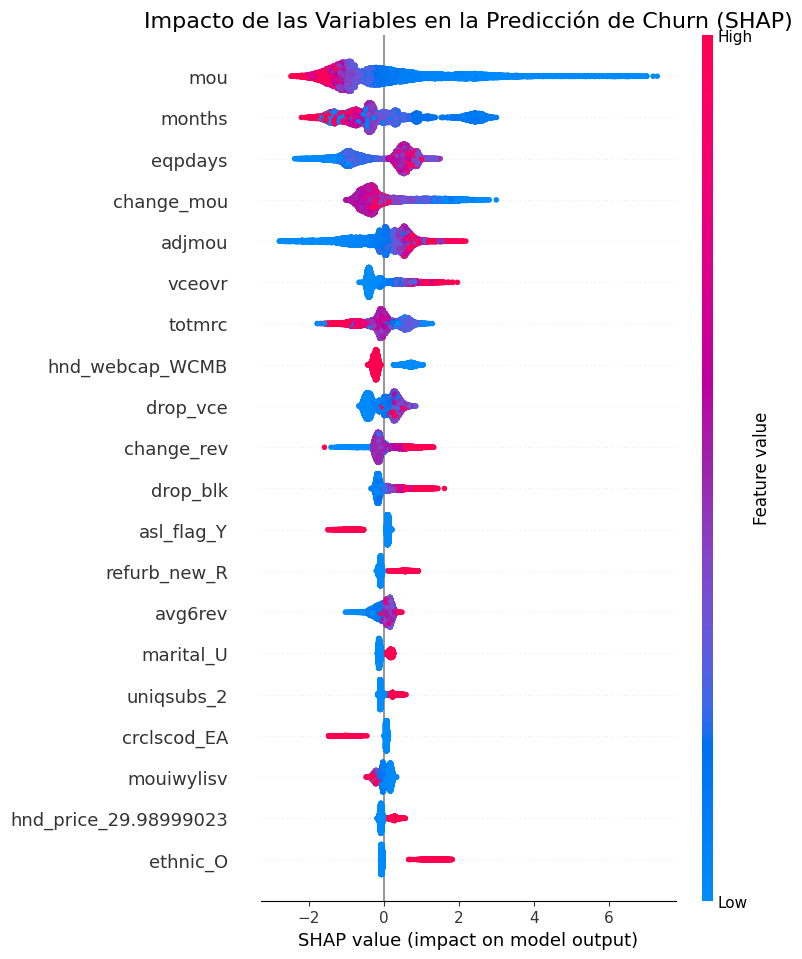

In [126]:
# PASO 3: VISUALIZAR EL SUMMARY PLOT
print("\n--- Generando el Summary Plot de SHAP ---")

# Usamos los valores SHAP calculados (shap_values), pero para la visualización
# le pasamos el DataFrame de test ANTES del rebalanceo.
# De esta forma, los nombres de las variables son correctos y los valores en el gráfico
# están en su escala original, no entre -1 y 1.

# Asegurarse de que shap_values[1] es una matriz 2D
shap_matrix = shap_values
if shap_matrix.ndim == 1:
    shap_matrix = shap_matrix.reshape(-1, 1)

shap.summary_plot(
    shap_matrix,  # Usamos los valores para la clase positiva (Churn = 1)
    X_test_final, # Pasamos el DataFrame con los nombres de columna correctos
    plot_type="dot",
    show=False
)
plt.title("Impacto de las Variables en la Predicción de Churn (SHAP)", fontsize=16)
plt.show()



### Summary_plot


--- Gráfico de las 5 variables con mayor impacto medio ---


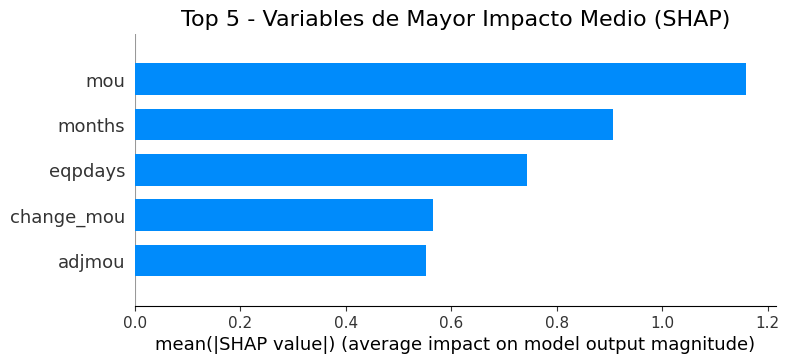

In [127]:
# PASO 4: VISUALIZAR LAS 5 VARIABLES MÁS IMPORTANTES
print("\n--- Gráfico de las 5 variables con mayor impacto medio ---")

shap.summary_plot(
    shap_values,
    X_test_final,
    plot_type="bar", # Usamos "bar" para ver la importancia media
    max_display=5,   # Mostramos solo las 5 primeras
    show=False
)
plt.title("Top 5 - Variables de Mayor Impacto Medio (SHAP)", fontsize=16)
plt.show()


## Interpretabilidad top 5 variables

Explicar muy brevemente cuales son las 5 variables que más impactan en el churn, y si el impacto es positivo o negativo.

La única variable que cambia respecto el lineal es vceovr por el change_mou. En este caso el change_mou indica un cambio en la media de minutos/mes del cliente.
Si el change_mou es decreciente mayor probabilidad de churn=1.

# Predicción

&#x26a0;&#xfe0f;
Realizar la predicción sobre el 100% de los clientes a predecir.  


&#x26a0;&#xfe0f;
Asegurarse de hacer la predicción en las mismas condiciones que el entrenamiento

In [128]:
# REALIZAR PREDICCIONES SOBRE EL CONJUNTO DE DATOS 'PREDICT'

print("\n--- Paso 4: Generando predicciones para los nuevos datos ---")

# 1. Obtener las probabilidades para el conjunto de predicción
predict_probabilities = final_model.predict_proba(X_predict_final)[:, 1]

# 2. Aplicar el umbral óptimo para obtener la predicción de clase final
predict_final_classes = (predict_probabilities >= best_threshold).astype(int)

print(f"Predicciones generadas para {len(predict_final_classes)} clientes.")
print(f"Número de clientes predichos como Churn (1): {np.sum(predict_final_classes)}")





--- Paso 4: Generando predicciones para los nuevos datos ---
Predicciones generadas para 1475 clientes.
Número de clientes predichos como Churn (1): 673


Imprimir los 20 clientes más propensos a irse

In [129]:
# PREPARAR Y EXPORTAR EL ARCHIVO DE PREDICCIÓN FINAL
print("\n--- Paso 5: Creando el archivo de entrega ---")

# 1. Crear un nuevo DataFrame para los resultados
submission_df = pd.DataFrame()

# 2. Añadir el Customer_ID (recuperándolo del dataframe original de predicción)
# Es importante asegurarse de que el índice se alinea correctamente
submission_df['customer_id'] = predict_df['Customer_ID'].reset_index(drop=True)

# 3. Añadir las columnas de predicción
submission_df['predict'] = predict_final_classes
submission_df['predict_proba'] = predict_probabilities


# 4. Mostrar los 20 clientes con mayor probabilidad de churn
print("\nTop 20 clientes con mayor probabilidad de Churn:")
top_20_churners = submission_df.sort_values(by='predict_proba', ascending=False)
print(top_20_churners)



--- Paso 5: Creando el archivo de entrega ---

Top 20 clientes con mayor probabilidad de Churn:
      customer_id  predict  predict_proba
888       1054479        1       0.999999
444       1025343        1       0.999999
1222      1074314        1       0.999999
496       1028659        1       0.999996
1255      1076249        1       0.999995
...           ...      ...            ...
24        1001712        0       0.000029
394       1023134        0       0.000026
1350      1083050        0       0.000023
160       1009855        0       0.000022
29        1002355        0       0.000004

[1475 rows x 3 columns]


Imprimir el len del archivo de predicción

In [130]:
len(top_20_churners)

1475

# Exportar predicción

Exportar un archivo excel con solamente 3 columnas, llamadas 'customer_id', 'predict' y 'predict_proba', **en minúscula**

In [131]:

# 5. Guardar el archivo en formato Excel
submission_filename = 'churn_predictions_final.xlsx'
submission_df.to_excel(submission_filename, index=False)

print(f"\n Predicciones guardadas en el archivo: '{submission_filename}'")


 Predicciones guardadas en el archivo: 'churn_predictions_final.xlsx'
